# Data Downloading and Preprocessing

In [1]:
import os
import glob
import json
import sys
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import rasterio
import rioxarray
import xarray as xr
from tqdm import tqdm
from pyproj import Geod

In [2]:
# ── USGS Credentials (set as env vars or replace directly)
USERNAME = os.environ.get("USGS_USERNAME", "Rishi_677")
TOKEN = os.environ.get("USGS_TOKEN", "5Fdntjd2uEgeVHXQ@nEv0M@za847T!11MhPKLKH80VDTd1sRMufUV1@s1_r6qS6w")

# ── AOI: Potrero De Garay, Argentina
AOI_LON, AOI_LAT = -64.53, -31.79
AOI_BOUNDS = [-64.57541111111111, -31.82181111111111, -64.48602222222222, -31.767622222222222]
MIN_LON, MIN_LAT, MAX_LON, MAX_LAT = AOI_BOUNDS

DATASET = "landsat_ot_c2_l2"
OUTPUT_DIR = "../landsat_data"
BASE_URL = "https://m2m.cr.usgs.gov/api/api/json/stable/"

print(f"AOI Centre  : lon = {AOI_LON}, lat = {AOI_LAT}")
print(f"AOI Bounds  : {AOI_BOUNDS}")
print(f"Output Dir  : {OUTPUT_DIR}")

AOI Centre  : lon = -64.53, lat = -31.79
AOI Bounds  : [-64.57541111111111, -31.82181111111111, -64.48602222222222, -31.767622222222222]
Output Dir  : ../landsat_data


In [3]:
geod = Geod(ellps="WGS84")
lons = [MIN_LON, MAX_LON, MAX_LON, MIN_LON, MIN_LON]
lats = [MIN_LAT, MIN_LAT, MAX_LAT, MAX_LAT, MIN_LAT]

area, _ = geod.polygon_area_perimeter(lons, lats)
area_m2 = abs(area)
area_km2 = area_m2 / 1e6

print(f"AOI Area : {area_km2:.4f} km²")

AOI Area : 50.8655 km²


## Data Ingestion

In [4]:
# ESRI 10m LULC class definitions
LULC_CLASSES = {
    0:  ("Unlabeled Data","#5A5A5A"),
    1: ("Water","#02487E"),
    2: ("Trees","#05701E"),
    3: ("Grass","#A8D46F"),
    4: ("Flooded Veg.","#6FDAE3"),
    5: ("Crops","#48D806"),
    6: ("Scrub or Shrub","#C9A227"),
    7: ("Built Area","#A2A19D"),
    8: ("Bare Ground","#683B05"),
    9: ("Snow or Ice","#FFFFFF"),
    10: ("Clouds","#B5EEFF"),
    11: ("Rangeland","#E5B116"),
}

lulc_cmap = mcolors.ListedColormap([v[1] for v in LULC_CLASSES.values()])
lulc_bounds = list(LULC_CLASSES.keys()) + [max(LULC_CLASSES.keys()) + 1]
lulc_norm = mcolors.BoundaryNorm(lulc_bounds, lulc_cmap.N)
lulc_patches = [mpatches.Patch(color=v[1], label=f"{k} – {v[0]}") for k, v in LULC_CLASSES.items()]

print("LULC class map is as follows :\n")
for k, v in LULC_CLASSES.items():
    print(k, ":", v[0])

LULC class map is as follows :

0 : Unlabeled Data
1 : Water
2 : Trees
3 : Grass
4 : Flooded Veg.
5 : Crops
6 : Scrub or Shrub
7 : Built Area
8 : Bare Ground
9 : Snow or Ice
10 : Clouds
11 : Rangeland


### USGS M2M API – Login

In [5]:
url = BASE_URL + "login-token"
payload = {"username": USERNAME, "token": TOKEN}
response = requests.post(url, data=json.dumps(payload))

httpStatusCode = response.status_code
output = json.loads(response.text)

if output.get("errorCode"):
    print("Login error:", output); sys.exit()
if httpStatusCode == 403:
    print("401 Unauthorized"); sys.exit()
if httpStatusCode == 500:
    print("Server error 500"); sys.exit()

api_key = output["data"]
headers = {"X-Auth-Token": api_key}
print(f"Logged in successfully with Status : {httpStatusCode}")

Logged in successfully with Status : 200


In [6]:
url = BASE_URL + "scene-search"
payload = {"datasetName": DATASET, "temporalCoverage": {"startDate": "2026-01-01", "endDate": "2026-04-01"},
    "sceneFilter": {"cloudCoverFilter": {"max": 20, "min": 0},
    "spatialFilter": {"filterType": "mbr","lowerLeft":  {"latitude": AOI_LAT - 0.1, "longitude": AOI_LON - 0.1},
    "upperRight": {"latitude": AOI_LAT + 0.1, "longitude": AOI_LON + 0.1},},},"maxResults": 10,}

res = requests.post(url, json=payload, headers=headers)
data = res.json()

if data.get("errorCode"):
    raise Exception(data["errorMessage"])

scenes = data["data"]["results"]
if not scenes:
    raise ValueError("No scenes found for the given AOI and date range")

scenes = sorted(scenes, key=lambda x: x.get("cloudCover", 100))
print(f"Found {len(scenes)} scenes. Picking lowest cloud cover :\n")
for s in scenes:
    print(f"{s['entityId']}  Cloud : {s.get('cloudCover','?')}%   Date : {s.get('temporalCoverage', {}).get('startDate','?')}")

Found 10 scenes. Picking lowest cloud cover :

LC92290822026006LGN00  Cloud : 0%   Date : 2026-01-06 00:00:00
LC82290822026030LGN00  Cloud : 2%   Date : 2026-01-30 00:00:00
LC92290822026022LGN00  Cloud : 4%   Date : 2026-01-22 00:00:00
LC82290822026014LGN00  Cloud : 4%   Date : 2026-01-14 00:00:00
LC92300822026029LGN00  Cloud : 8%   Date : 2026-01-29 00:00:00
LC92290822026038LGN00  Cloud : 10%   Date : 2026-02-07 00:00:00
LC82290822026078LGN01  Cloud : 11%   Date : 2026-03-19 00:00:00
LC92290822026070LGN00  Cloud : 16%   Date : 2026-03-11 00:00:00
LC92290822026054LGN00  Cloud : 20%   Date : 2026-02-23 00:00:00
LC82300822026021LGN00  Cloud : 20%   Date : 2026-01-21 00:00:00


In [7]:
# Selecting the Best Scene

scene = scenes[0]
entity_id = scene["entityId"]

print(f"Selected Scene : {entity_id}")
print(f"Cloud Cover : {scene.get('cloudCover', 'N/A')}%")
print(f"Acquisition Date : {scene.get('temporalCoverage', {}).get('startDate', 'N/A')}")
print(f"Satellite : {scene.get('satellite', 'N/A')}")

Selected Scene : LC92290822026006LGN00
Cloud Cover : 0%
Acquisition Date : 2026-01-06 00:00:00
Satellite : N/A


In [8]:
url = BASE_URL + "download-options"
payload = {"datasetName": DATASET, "entityIds": [entity_id]}
res = requests.post(url, json=payload, headers=headers)
data = res.json()

if data.get("errorCode"):
    raise Exception(data["errorMessage"])

options = data["data"]
files_to_download = []

for item in options:
    if item["id"] != "632210d4770592cf":
        continue
    for f in item.get("secondaryDownloads", []):
        if f.get("available"):
            files_to_download.append({"entityId": f["entityId"], "productId": f["id"], "name": f["displayId"],})

print(f"{len(files_to_download)} band files available for download")

22 band files available for download


In [9]:
payload = {"downloads": [{"entityId": f["entityId"], "productId": f["productId"]} for f in files_to_download],"label": "landsat_download",}
res = requests.post(BASE_URL + "download-request", headers=headers, json=payload)
urls_data = res.json()
urls_all = urls_data["data"].get("availableDownloads", [])
id_to_name = {f["entityId"]: f["name"] for f in files_to_download}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"{len(urls_all)} download URL's received ")
print(f"Images saving to {OUTPUT_DIR} Folder")

22 download URL's received 
Images saving to ../landsat_data Folder


### Downloading Landsat Band Files

In [10]:
for item in urls_all:
    name = id_to_name.get(item.get("entityId", ""))
    if not name:
        name = item["url"].split("?")[0].split("/")[-1]

    path = os.path.join(OUTPUT_DIR, name)
    if os.path.exists(path) and os.path.getsize(path) > 100_000:
        print(f"Already exists, skipping: {name}")
        continue

    print(f"Downloading: {name}")
    r = requests.get(item["url"], stream=True)
    with open(path, "wb") as fh:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            fh.write(chunk)

requests.post(BASE_URL + "logout", headers=headers)
print("\nAll band files downloaded")

Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_ANG.txt
Downloading: LC09_L2SP_229082_20260106_20260107_02_T1_MTL.txt
Downloading: LC09_L2SP_229082_20260106_20260107_02_T1_MTL.xml
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_QA_PIXEL.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_QA_RADSAT.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B1.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B2.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B3.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B4.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B5.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B6.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_B7.TIF
Already exists, skipping: LC09_L2SP_229082_20260106_20260107_02_T1_SR_QA_AEROSOL.TIF
Already exists, 

In [11]:
base_path   = OUTPUT_DIR + "/"
BAND_LOOKUP = {"blue": "*_SR_B2.TIF", "green": "*_SR_B3.TIF", "red": "*_SR_B4.TIF", "nir": "*_SR_B5.TIF"}
band_files  = {}

for band, pattern in BAND_LOOKUP.items():
    matches = glob.glob(f"{base_path}{pattern}")
    if not matches:
        raise FileNotFoundError(f"Missing band file for '{band}' ({pattern})")
    band_files[band] = matches[0]
    print(f"{band} band Found , File : {os.path.basename(matches[0])}")

print("\nAll 4 required bands found.")

blue band Found , File : LC09_L2SP_229082_20260106_20260107_02_T1_SR_B2.TIF
green band Found , File : LC09_L2SP_229082_20260106_20260107_02_T1_SR_B3.TIF
red band Found , File : LC09_L2SP_229082_20260106_20260107_02_T1_SR_B4.TIF
nir band Found , File : LC09_L2SP_229082_20260106_20260107_02_T1_SR_B5.TIF

All 4 required bands found.


### Downloading ESRI LULC Map (10 m)

In [12]:
esri_url = "https://ic.imagery1.arcgis.com/arcgis/rest/services/Sentinel2_10m_LandCover/ImageServer/exportImage"
parameters = {"bbox": f"{MIN_LON},{MIN_LAT},{MAX_LON},{MAX_LAT}", "bboxSR": 4326, "size": "2048,2048", 
            "imageSR": 4326, "format": "tiff", "pixelType": "U8", "noData": 0, "f": "image" }

response = requests.get(esri_url, params=parameters)

print("Status:", response.status_code)

content_type = response.headers.get("Content-Type", "")
if "image" not in content_type:
    print("\nServer returned error payload")
    print(response.text[:1000])
    raise Exception("Download failed : response is not an image")

with open("lulc.tif", "wb") as fh:
    fh.write(response.content)

print("File saved as lulc.tif")
lulc_raw = rioxarray.open_rasterio("lulc.tif", masked=True).squeeze()
print(f"\nLULC downloaded")
print(f"Shape : {lulc_raw.shape}")
print(f"CRS : {lulc_raw.rio.crs}")

vals = lulc_raw.values
unique_vals = sorted(int(v) for v in np.unique(vals[~np.isnan(vals)]))
print(f"Unique class IDs present: {unique_vals}")

Status: 200
File saved as lulc.tif

LULC downloaded
Shape : (2048, 2048)
CRS : EPSG:4326
Unique class IDs present: [1, 2, 5, 7, 11]


## Preprocessing the Data

In [13]:
def read_band(path):
    return rioxarray.open_rasterio(path, masked=True).rio.clip_box(*AOI_BOUNDS, crs="EPSG:4326")

ls_bands = []
for name in ["blue", "green", "red", "nir"]:
    ls_bands.append(read_band(band_files[name]).assign_coords(band=[name]))

ls_data = xr.concat(ls_bands, dim="band").squeeze()
print(f"Landsat stack shape : {ls_data.shape} ")
print(f"CRS : {ls_data.rio.crs}")

Landsat stack shape : (4, 205, 286) 
CRS : EPSG:32620


In [14]:
lulc_data = lulc_raw.rio.reproject_match(ls_data)
print(f"LULC reprojected to match Landsat ")
print(f"Shape : {lulc_data.shape}")
print(f"Classes present after clip : {sorted(int(v) for v in np.unique(lulc_data.values) if not np.isnan(v))}")

LULC reprojected to match Landsat 
Shape : (205, 286)
Classes present after clip : [1, 2, 7, 11]


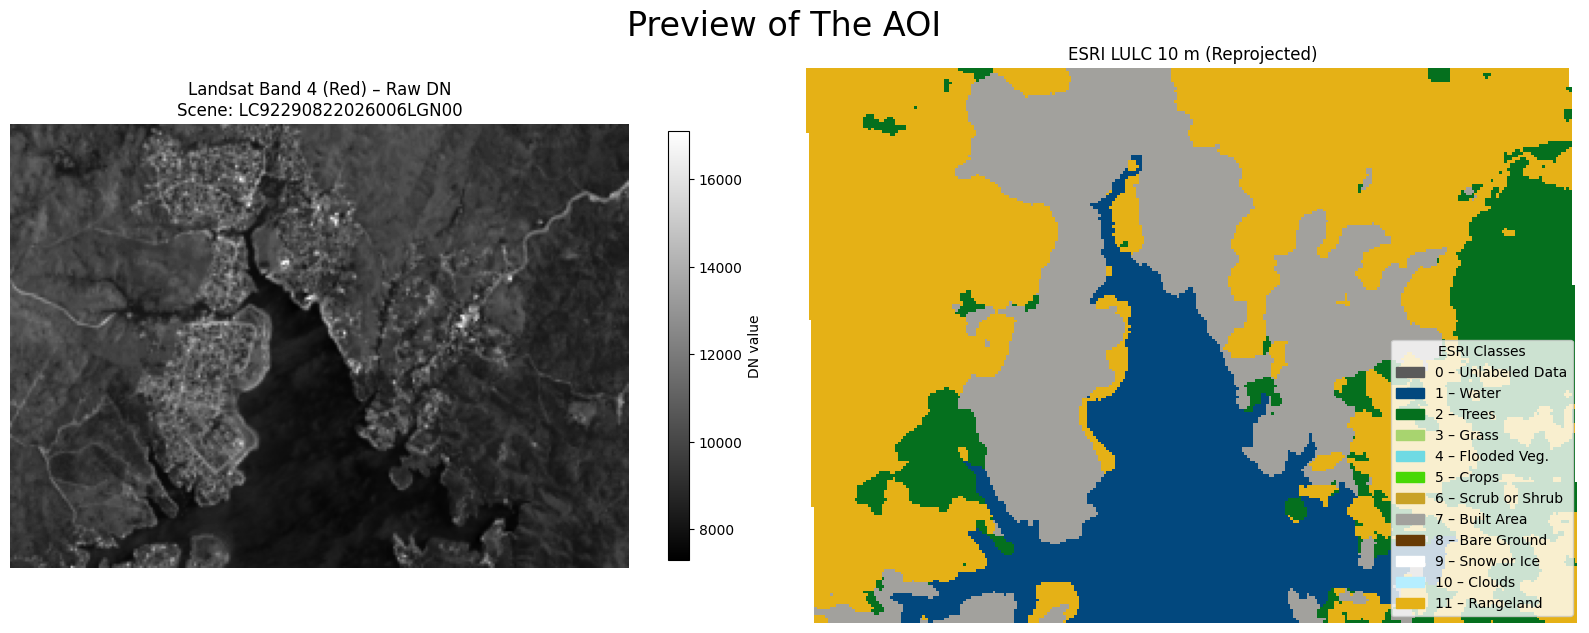

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle("Preview of The AOI  ", fontsize=24)

raw_red = ls_data.sel(band="red").values.astype(float)
raw_red_vis = np.where(raw_red > 0, raw_red, np.nan)
im0 = axes[0].imshow(raw_red_vis, cmap="gray")
plt.colorbar(im0, ax=axes[0], shrink=0.75, label="DN value")
axes[0].set_title(f"Landsat Band 4 (Red) – Raw DN\nScene: {entity_id}")
axes[0].axis("off")

im1 = axes[1].imshow(lulc_data.values, cmap=lulc_cmap, norm=lulc_norm, interpolation="nearest")
axes[1].legend(handles=lulc_patches, loc="lower right", title="ESRI Classes")
axes[1].set_title("ESRI LULC 10 m (Reprojected)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Surface Reflectance Scaling

ls_scaled = ls_data.astype(np.float32) * 0.0000275 - 0.2
ls_scaled = np.clip(ls_scaled, 0, 1)

print(f"Min reflectance: {float(ls_scaled.min()):.4f}")
print(f"Max reflectance: {float(ls_scaled.max()):.4f}")

Min reflectance: 0.0000
Max reflectance: 0.5619



Displaying the True Colour Composite of the Image



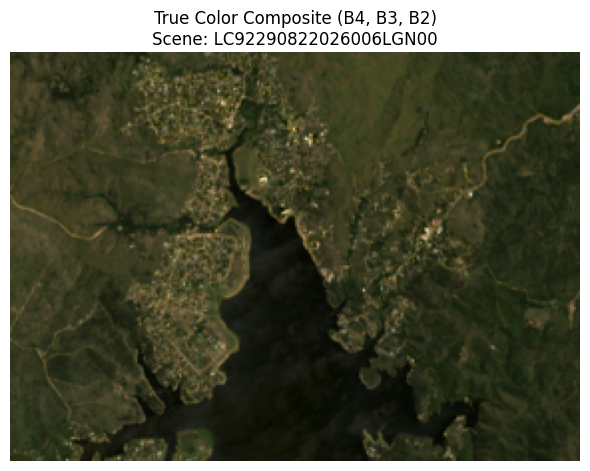

In [17]:
rgb = ls_scaled.sel(band=["red", "green", "blue"]).values
rgb_vis = np.clip(rgb / 0.3, 0, 1)
print("\nDisplaying the True Colour Composite of the Image\n")
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(np.transpose(rgb_vis, (1, 2, 0)))
ax.set_title(f"True Color Composite (B4, B3, B2)\nScene: {entity_id}")
ax.axis("off")
plt.tight_layout()
plt.show()

### NDVI Calculation

In [18]:
red = ls_scaled.sel(band="red")
nir = ls_scaled.sel(band="nir")
ndvi = (nir - red)/(nir + red + 1e-8)

print(f"NDVI min  : {float(ndvi.min()):.4f}")
print(f"NDVI max  : {float(ndvi.max()):.4f}")
print(f"NDVI mean : {float(ndvi.mean()):.4f}")
print(f"NDVI std  : {float(ndvi.std()):.4f}")

NDVI min  : -0.8065
NDVI max  : 0.9677
NDVI mean : 0.5345
NDVI std  : 0.2343


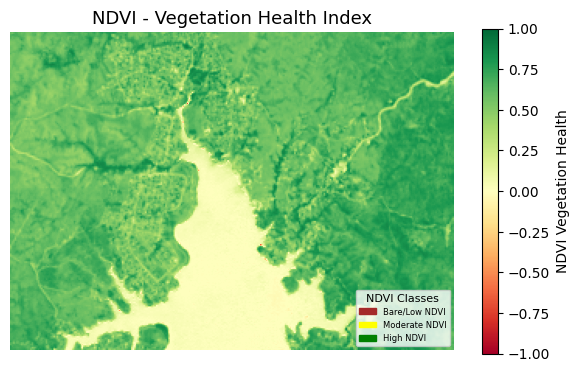

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax, shrink=0.57, label="NDVI")
cbar.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
legend_patches = [mpatches.Patch(color='brown', label='Bare/Low NDVI'),
    mpatches.Patch(color='yellow', label='Moderate NDVI'),
    mpatches.Patch(color='green', label='High NDVI')]
ax.legend(handles=legend_patches, loc='lower right', fontsize=6, title="NDVI Classes",title_fontsize=8)
cbar.set_label("NDVI Vegetation Health")
ax.set_title("NDVI - Vegetation Health Index", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. ESRI LULC Map with Legend

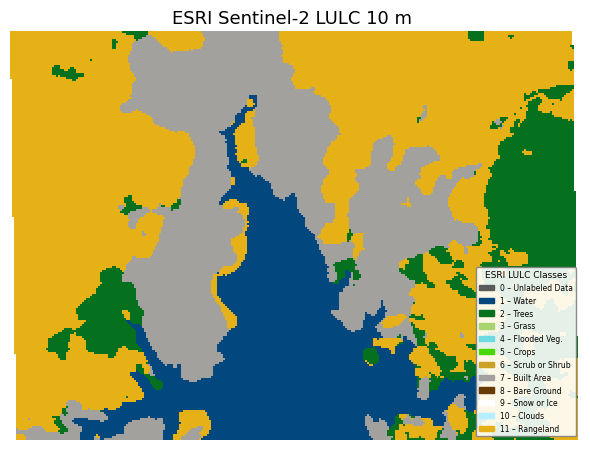

In [20]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(lulc_data.values, cmap=lulc_cmap, norm=lulc_norm, interpolation="nearest")
ax.legend(handles=lulc_patches, loc="lower right", fontsize=5.5, title="ESRI LULC Classes", title_fontsize=6.5, framealpha=0.9, edgecolor="gray")
ax.set_title("ESRI Sentinel-2 LULC 10 m ", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Full Comparison – True Color | NDVI | LULC

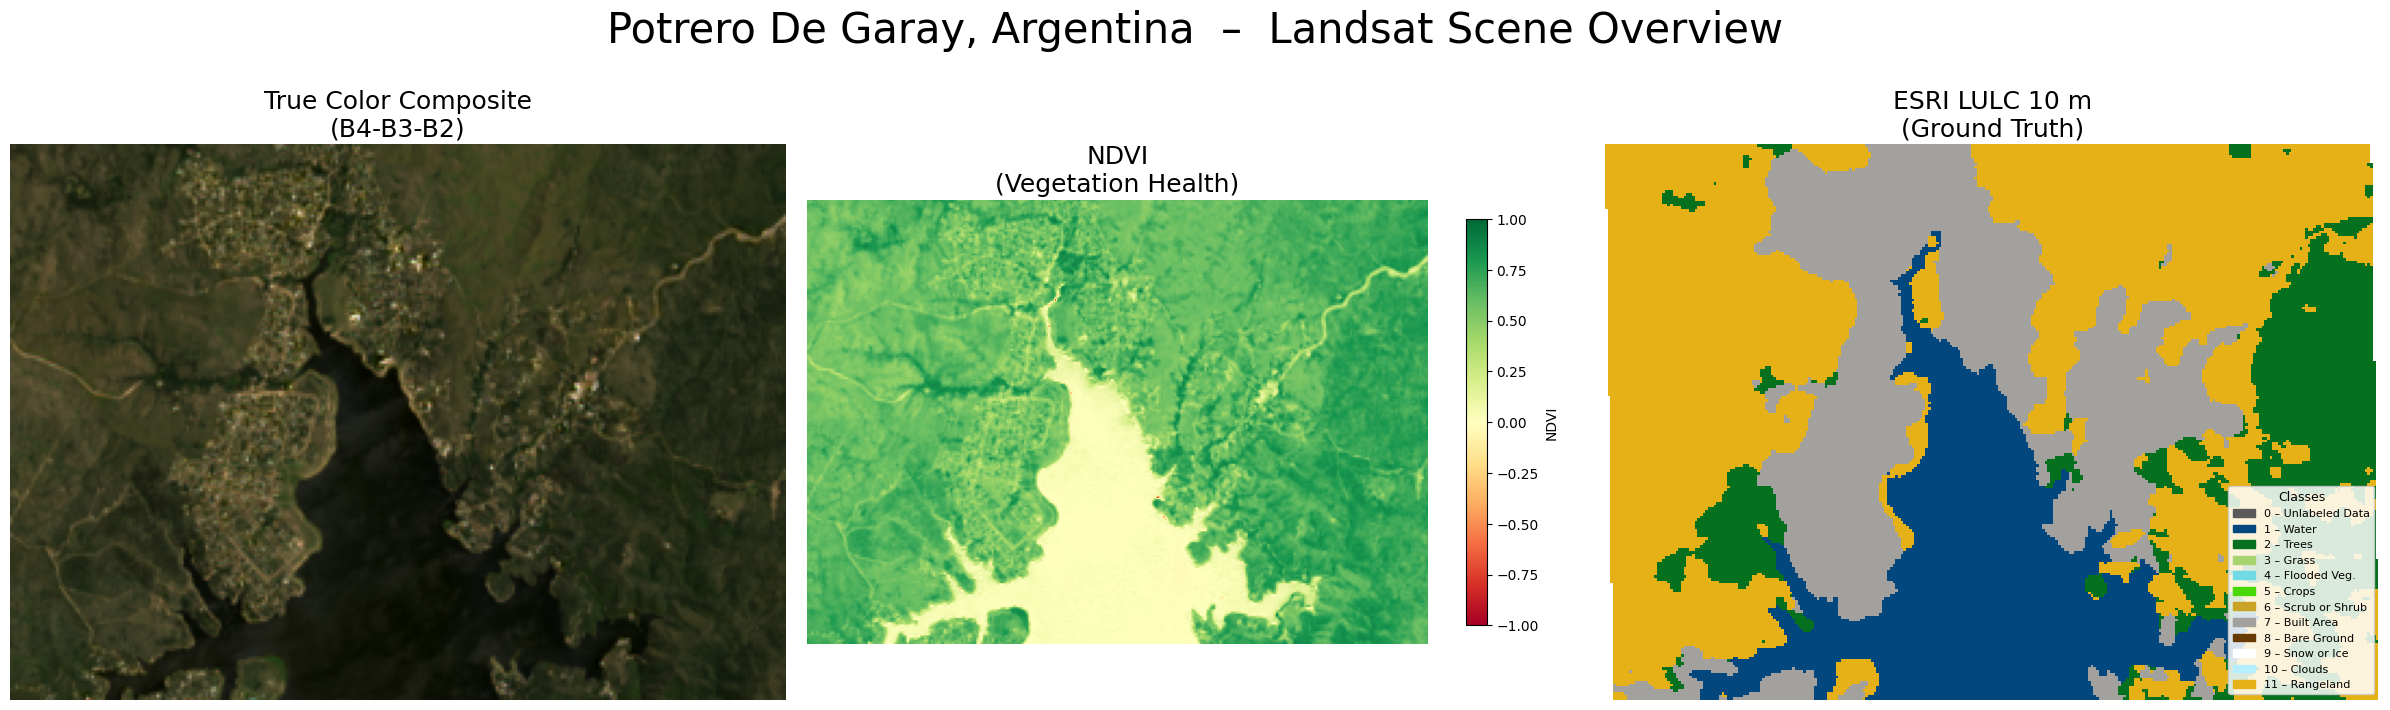

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("Potrero De Garay, Argentina  –  Landsat Scene Overview", fontsize=30)

# Panel 1: TCC
axes[0].imshow(np.transpose(rgb_vis, (1, 2, 0)))
axes[0].set_title("True Color Composite\n(B4-B3-B2)", fontsize=18)
axes[0].axis("off")

# Panel 2: NDVI
im1 = axes[1].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
cbar1 = plt.colorbar(im1, ax=axes[1], shrink=0.57, label="NDVI")
axes[1].set_title("NDVI\n(Vegetation Health)", fontsize=18)
axes[1].axis("off")

# Panel 3: LULC
axes[2].imshow(lulc_data.values, cmap=lulc_cmap, norm=lulc_norm, interpolation="nearest")
axes[2].legend(handles=lulc_patches, loc="lower right", fontsize=8,title="Classes", title_fontsize=9, framealpha=0.85)
axes[2].set_title("ESRI LULC 10 m\n(Ground Truth)", fontsize=18)
axes[2].axis("off")

plt.tight_layout()
plt.show()